In [1]:
import numpy as np
a = np.array([3]*3+[1])
a
import yapss
from yapss import math
import importlib
import setup_and_solve
importlib.reload(setup_and_solve)
from setup_and_solve import *
import matplotlib.pyplot as plt
import time

In [2]:
ap = ArdupilotParameters()
optim_params = OptimizerParameters()
start = StartConstraint(0, 0, 0, 0)
constraints = [Constraint(25, 50, 0)]
traj = Trajectory(start, constraints)
optim = Optimizer(traj, ap, optim_params)
dist = traj.distances()

In [3]:
st = np.array([0, 0, 0, 0])
tgt = np.array([-100, 0, 50])
a = time.perf_counter()
dist = np.linalg.norm(st[0:3] - tgt)
b = time.perf_counter()
z_dist = np.linalg.norm(st[2] - tgt[2])
print(b-a)
print(z_dist)
dist = np.sqrt((st[0] - tgt[0])**2 + (st[1] - tgt[1])**2 + (st[2] - tgt[2])**2)

problem = yapss.Problem(name = "Constraints to Trajectory",
                                nx = [4],
                                ns = 2)
begin = time.perf_counter()

def continuous(arg):
    x, y, z, phi = arg.phase[0].state
    bank, omega = arg.parameter
    xdot = ap.V_cruise*math.cos(phi)
    ydot = ap.V_cruise*math.sin(phi)
    zdot = omega
    phidot = 9.80665*math.tan(bank)/ap.V_cruise
    arg.phase[0].dynamics = [xdot, ydot, zdot, phidot]

problem.functions.continuous = continuous

problem.bounds.phase[0].initial_time.lower = problem.bounds.phase[0].initial_time.upper = 0
problem.bounds.phase[0].final_time.lower = dist/ap.V_cruise


problem.guess.phase[0].time = [0, 10]


segments, points = 9, 3
problem.mesh.phase[0].collocation_points = segments * [points]
problem.mesh.phase[0].fraction = segments * [1 / segments]
problem.ipopt_options.tol = 1e-3
finish = time.perf_counter()
print(finish-begin)

8.440000237897038e-05
50.0
0.0005130999488756061


In [4]:
def objective(arg):
    x, y, z, phi= arg.phase[0].final_state
    arg.objective = arg.phase[0].final_time + (x - tgt[0])**2 + (y - tgt[1])**2 + (z - tgt[2])**2

problem.functions.objective = objective

problem.bounds.phase[0].final_time.upper = 2*np.pi*ap.max_turn/ap.V_cruise + z_dist/ap.V_cruise
problem.bounds.phase[0].initial_state.lower = problem.bounds.phase[0].initial_state.upper = st

problem.guess.phase[0].state = [
    [st[0], tgt[0]],
    [st[1], tgt[1]],
    [st[2], tgt[2]],
    [st[3], 0]
    ]

if np.cos(st[3])*(tgt[1] - st[1]) - np.sin(st[3])*(tgt[0] - st[0]) > 0:
    bank_guess = np.pi/4
    problem.bounds.parameter.lower = [ap.roll_min_rad, -ap.max_desc]
    problem.bounds.parameter.upper = [ap.roll_limit_rad, ap.max_climb]
else:
    bank_guess = -np.pi/4
    problem.bounds.parameter.lower = [-ap.roll_limit_rad, -ap.max_desc]
    problem.bounds.parameter.upper = [-ap.roll_min_rad, ap.max_climb]
problem.guess.parameter = [bank_guess, 0]

In [5]:
begin = time.perf_counter()
sol = problem.solve()
finish = time.perf_counter()
print(finish-begin)
x, y, z, phi = sol.phase[0].state

0.09253939997870475


153.5921236546311
-5.095113362410642
0.3255375263361859


array([   0.        ,  184.0581342 ,  347.3408312 ,  470.6953337 ,
        540.92041931,  548.9645755 ,  495.04472716,  384.21754061,
        230.02205949,   49.38463803, -136.82704098, -307.30991354,
       -443.10538782, -527.96415521, -553.22932629, -514.89861067,
       -418.44906323, -273.89715037,  -98.42928224])

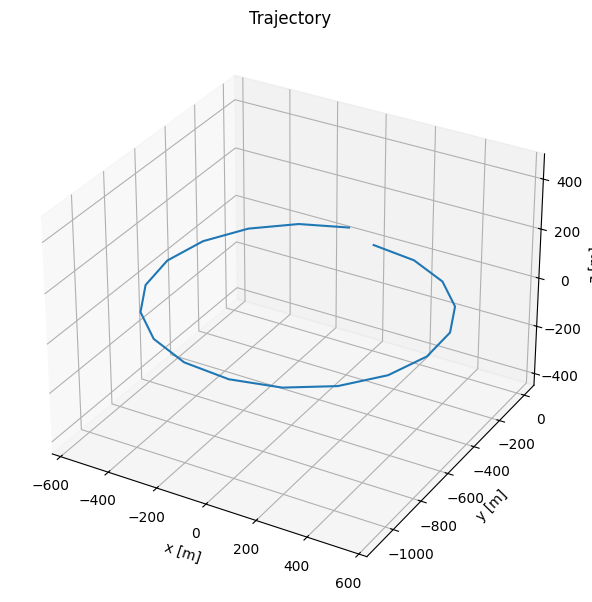

In [6]:
fig = plt.figure(figsize=(20,16))
fig.tight_layout()
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
# Go phase by phase so that each phase gets its own color.
ax1.plot(x, y, z)
ax1.set_aspect('equal', adjustable='datalim')
ax1.set_xlabel("x [m]")
ax1.set_ylabel("y [m]")
ax1.set_zlabel("z [m]")
ax1.set_title("Trajectory")
ax1.grid(True)
print(sol.phase[0].final_time)
print(np.rad2deg(sol.parameter[0]))
print(sol.parameter[1])
x

In [7]:
ap = ArdupilotParameters()
optim_params = OptimizerParameters(time_weight=10)
start = StartConstraint(0, 0, 0, 0)
constraints = [Constraint(-50, 0, 50)]
traj = Trajectory(start, constraints)
optim = Optimizer(traj, ap, optim_params)

In [8]:
optim.presolve()

{'constr0_time': array([ 0.        ,  3.33984793,  6.67969586, 10.01954379, 13.35939172,
        16.69923965, 20.03908758, 23.37893551, 26.71878344, 30.05863137,
        33.3984793 , 36.73832723, 40.07817516, 43.41802309, 46.75787102,
        50.09771895, 53.43756688, 56.77741481, 60.11726274]),
 'constr0_state': array([[ 0.00000000e+00,  7.20640600e+01,  1.36115071e+02,
          1.84756191e+02,  2.12853640e+02,  2.16853453e+02,
          1.96740591e+02,  1.54354286e+02,  9.48048026e+01,
          2.45222553e+01, -4.84870052e+01, -1.16006943e+02,
         -1.70627674e+02, -2.05931264e+02, -2.18336655e+02,
         -2.06023665e+02, -1.70802201e+02, -1.16243839e+02,
         -4.87599269e+01],
        [ 0.00000000e+00, -1.23591928e+01, -4.76217272e+01,
         -1.02211285e+02, -1.69713224e+02, -2.42719935e+02,
         -3.13015391e+02, -3.72592061e+02, -4.15016551e+02,
         -4.35174476e+02, -4.31221469e+02, -4.03167301e+02,
         -3.54561189e+02, -2.90532798e+02, -2.18476676e+02,

In [9]:
xt, yt, zt, phit = optim.initial["constr0_state"]
a, b, c = optim.initial["constr0_params"]

-12.738336177260019 22.0 0.8317078587810138


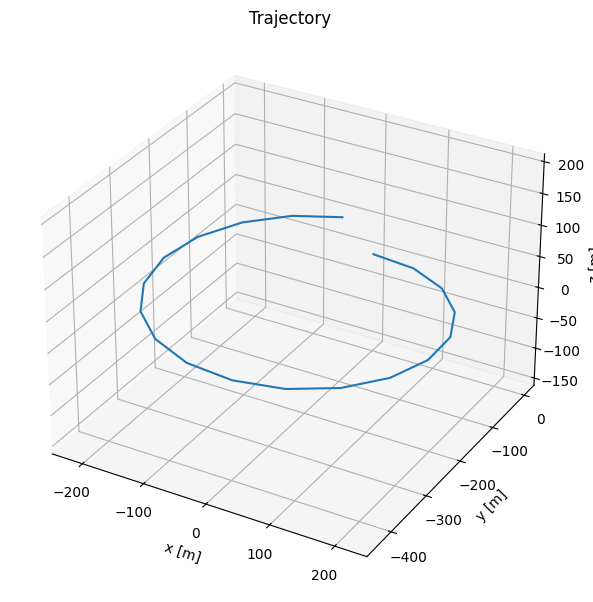

In [10]:
fig = plt.figure(figsize=(20,16))
fig.tight_layout()
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
# Go phase by phase so that each phase gets its own color.
ax1.plot(xt, yt, zt)
ax1.set_aspect('equal', adjustable='datalim')
ax1.set_xlabel("x [m]")
ax1.set_ylabel("y [m]")
ax1.set_zlabel("z [m]")
ax1.set_title("Trajectory")
ax1.grid(True)
print(np.rad2deg(a), b, c)

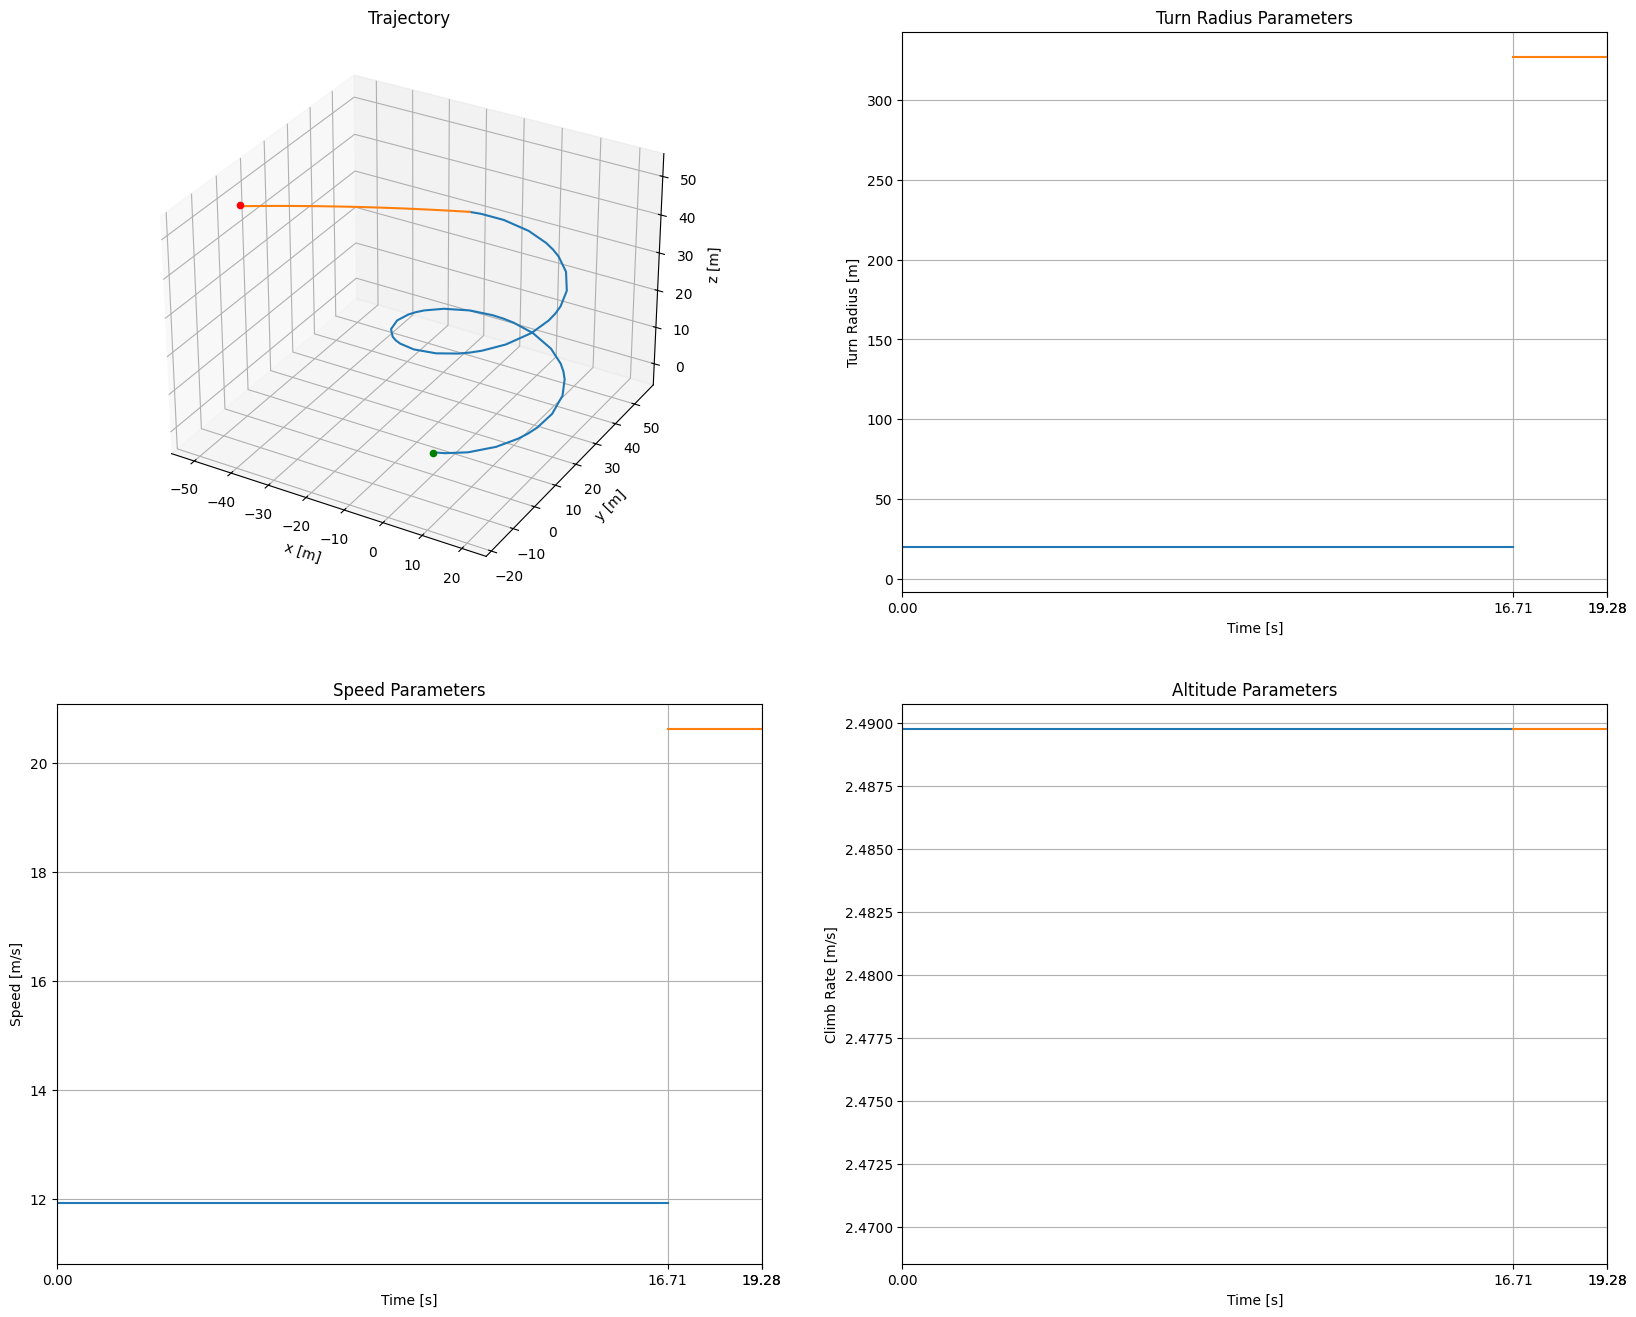

In [11]:
optim.plot()

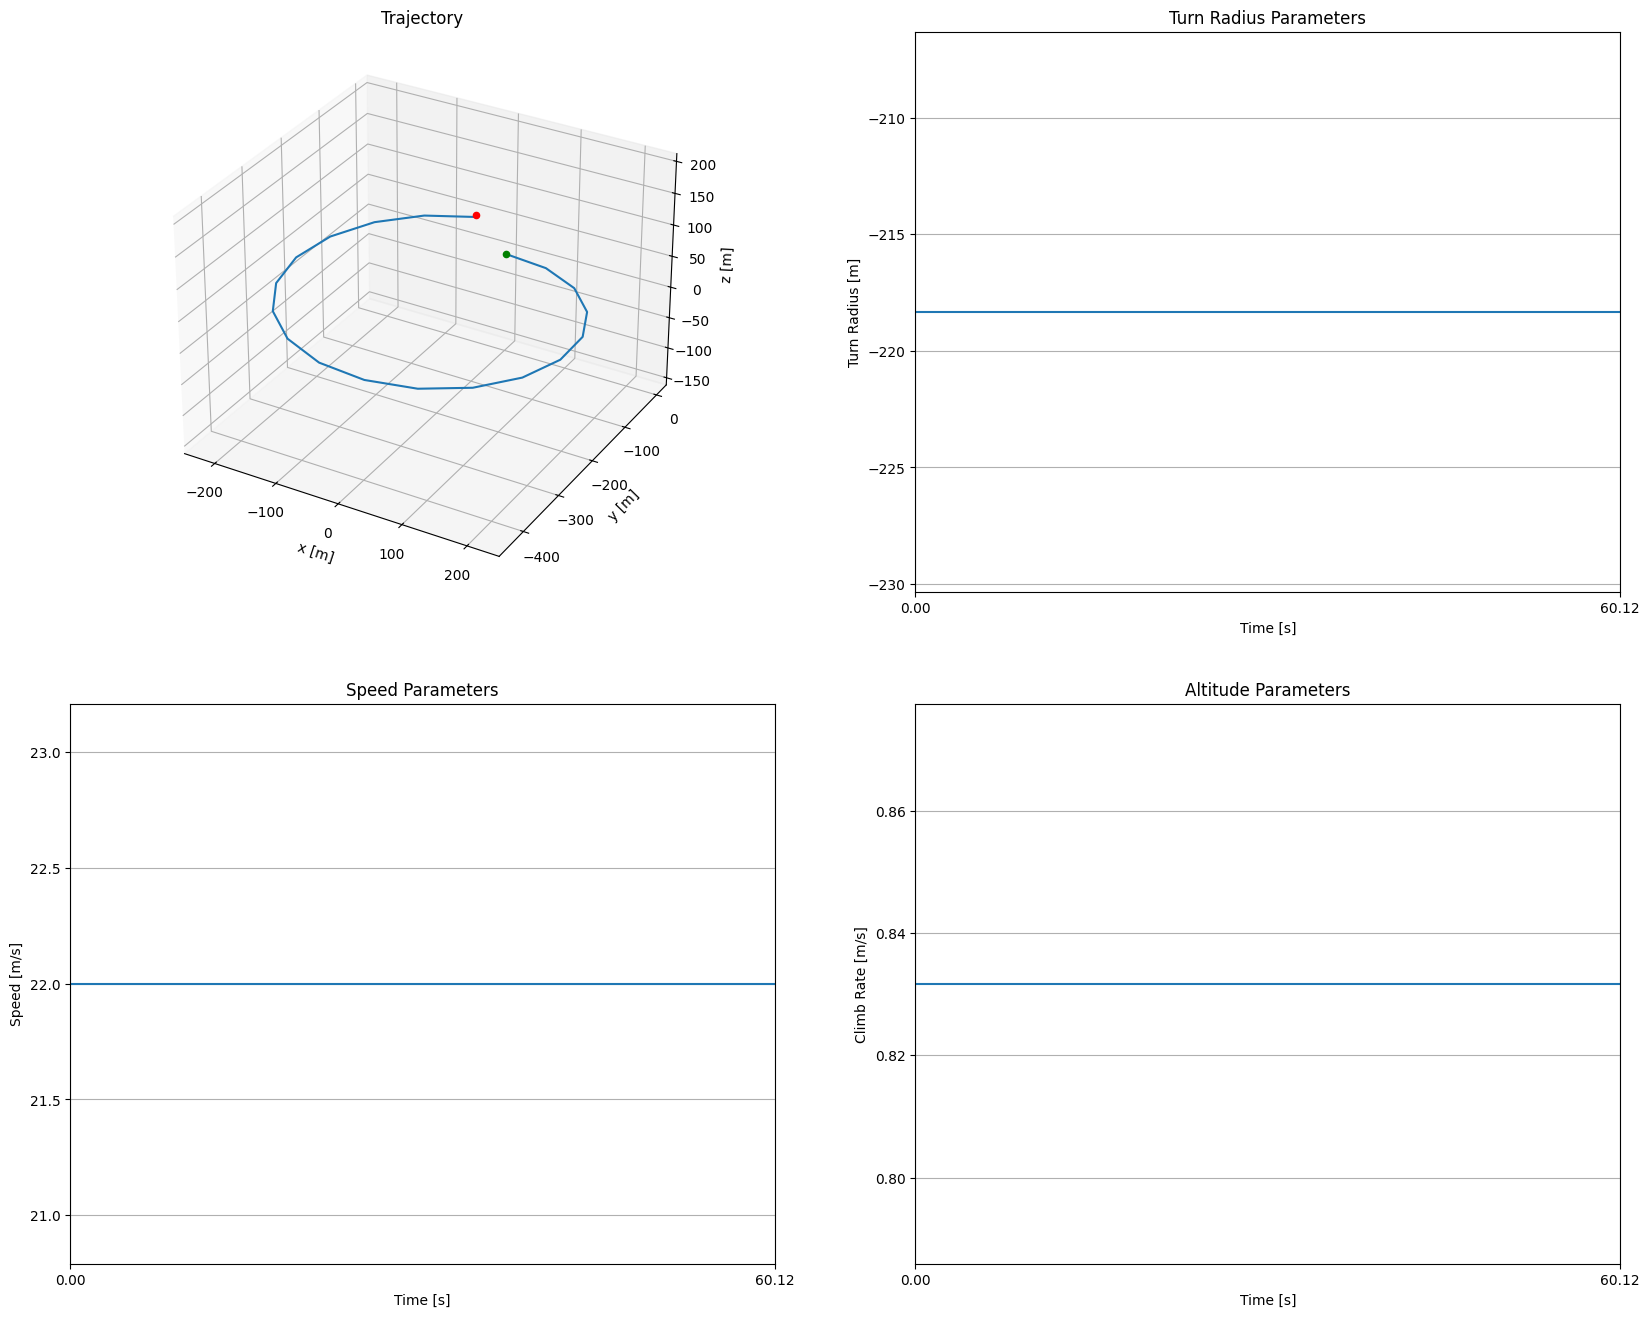

In [12]:
optim.presolve_plot()